In [1]:
import torch

In [2]:
torch.__version__

'2.9.0+cu128'

In [3]:
torch.cuda.is_available()

True

In [4]:
import os, re, time, json, random, math, gc
from pathlib import Path
import numpy as np
import pandas as pd
from PIL import Image

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import models, transforms
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
from pathlib import Path
from tqdm import tqdm



In [5]:
# --- PRE/POSTPROCESADO de fondo de ojo ---
import cv2
from PIL import Image

def crop_fundus_rgb(im_pil: Image.Image) -> Image.Image:
    arr = np.array(im_pil)
    g = cv2.cvtColor(arr, cv2.COLOR_RGB2GRAY)
    m = (g > 5).astype(np.uint8) * 255
    cnts, _ = cv2.findContours(m, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    if not cnts:
        return im_pil
    cnt = max(cnts, key=cv2.contourArea)
    (cx, cy), r = cv2.minEnclosingCircle(cnt)   
    cx, cy, r = int(cx), int(cy), int(r * 0.98)
    x0, x1 = max(0, cx - r), min(arr.shape[1], cx + r)
    y0, y1 = max(0, cy - r), min(arr.shape[0], cy + r)
    arr = arr[y0:y1, x0:x1]
    return Image.fromarray(arr)

def clahe_green(im_pil: Image.Image) -> Image.Image:
    arr = np.array(im_pil)
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    arr[..., 1] = clahe.apply(arr[..., 1])  # canal G
    return Image.fromarray(arr)


In [6]:
# ----------------------------
# CONFIG
# ----------------------------
DATA_ROOT   = Path(r"C:\Users\Victoria\Desktop\data\datos_raw")  # <- ajusta si cambiaste
DATASETS    = ["aptos_2019", "eyePACS", "idrid", "messidor"]     # usa los que tengas
ARCH        = "mobilenet_v3_large"                                   # "resnet34"|"efficientnet_b0"|"mobilenet_v3_large"|"inception_v3"
IMG_SIZE    = 224                                                    # MobileNetV3 usa 224x224
N_CLASSES   = 5

BATCH_BASE  = 16             # si falta VRAM, baja a 8 o 4
BATCH       = max(1, BATCH_BASE // 2)   # p.ej. 8 si BATCH_BASE=16
EPOCHS      = 25
LR          = 3e-4
WD          = 1e-4
SEED        = 42
NUM_WORKERS = 0
PIN_MEMORY  = True

VAL_SIZE    = 0.15                  # proporción de validación desde train
USE_CLASS_WEIGHTS     = True
EARLY_STOP_PATIENCE   = 5
BALANCE_MAX_PER_CLASS = 1000        # None = sin tope; recomendable 500-1000 para que eyePACS no domine

# ====== RUTA DE SALIDA PARA TUS RESULTADOS ======
# TODO: esta es la carpeta que quieres usar, la tuya del Desktop:
BASE_OUT = Path(r"C:\Users\Victoria\Desktop\data\datos_raw\resultados_dl")

# Creamos una subcarpeta por run (sin 'prueba' y con el modelo correcto)
RUN_TAG  = f"{ARCH}_img{IMG_SIZE}_bs{BATCH}_lr{LR}".replace("/", "-")
OUTDIR   = BASE_OUT / f"COMBINED_TRAIN_ONLY_{'-'.join(DATASETS)}_{RUN_TAG}"
OUTDIR.mkdir(parents=True, exist_ok=True)

torch.backends.cudnn.benchmark = True
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

def set_seed(s=SEED):
    random.seed(s); np.random.seed(s); torch.manual_seed(s); torch.cuda.manual_seed_all(s)
set_seed(SEED)
print("Device:", DEVICE)

print("OUTDIR:", OUTDIR)


Device: cuda
OUTDIR: C:\Users\Victoria\Desktop\data\datos_raw\resultados_dl\COMBINED_TRAIN_ONLY_aptos_2019-eyePACS-idrid-messidor_mobilenet_v3_large_img224_bs8_lr0.0003


In [7]:
import wandbwandb.login()  # usa la sesi?n local o WANDB_API_KEY


wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: Appending key for api.wandb.ai to your netrc file: C:\Users\Victoria\_netrc
wandb: Appending key for api.wandb.ai to your netrc file: C:\Users\Victoria\_netrc
wandb: Currently logged in as: victoria-castro (victoria-castro-universidad-peruana-cayetano-heredia) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin
wandb: Currently logged in as: victoria-castro (victoria-castro-universidad-peruana-cayetano-heredia) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


True

In [8]:
from pathlib import Path
import os

# === Carpeta local para archivos de W&B ===
WANDB_LOCAL_DIR = Path(r"C:\Users\Victoria\Desktop\data\datos_raw\resultados_dl\_wandb_runs")
WANDB_LOCAL_DIR.mkdir(parents=True, exist_ok=True)

# Define la variable de entorno (W&B usará esta ruta)
os.environ["WANDB_DIR"] = str(WANDB_LOCAL_DIR)

# === Inicializar el run ===
run = wandb.init(
    project="retinopatia-diabetica",
    entity="victoria-castro-universidad-peruana-cayetano-heredia",  # tu cuenta/org
    name=RUN_TAG,                                   # ejemplo: efficientnet_b0_img224_bs32_lr0.001
    tags=["DL", "CUDA", ARCH] + DATASETS,           # etiquetas reales
    dir=os.environ["WANDB_DIR"],                    # carpeta local donde se guardan los logs
    config={
        "epochs": EPOCHS,
        "batch_size": BATCH,
        "lr": LR,
        "weight_decay": WD,
        "img_size": IMG_SIZE,
        "arch": ARCH,
        "datasets": DATASETS,
        "device": str(DEVICE),
        "outdir": str(OUTDIR),
    },
)


In [9]:
# ----------------------------
# Utilidades
# ----------------------------
IMAGE_COL_CANDIDATES = {"image","filename","file","img","imagen","Image","File","Filename"}
LABEL_COL_CANDIDATES = {"level","label","labels","grade","diagnosis","target","class","DR","DRGrade","Severity"}

def resolve_img(basename: str, folder: Path):
    exts = (".png",".jpg",".jpeg",".tif",".tiff",".bmp",".JPG",".JPEG",".PNG")
    s = str(basename)
    if any(s.endswith(e) for e in exts):
        p = folder / s
        return str(p) if p.exists() else None
    for e in exts:
        p = folder / f"{s}{e}"
        if p.exists():
            return str(p)
    return None

def read_train_only(dataset_name: str):
    root = DATA_ROOT / dataset_name
    csv_path = root / "train.csv"
    if not csv_path.exists():
        print(f"[AVISO] {dataset_name} no tiene train.csv")
        return None
    df = pd.read_csv(csv_path)
    # columnas
    img_col = None
    for c in df.columns:
        if c in IMAGE_COL_CANDIDATES or c.lower() in {x.lower() for x in IMAGE_COL_CANDIDATES}:
            img_col = c; break
    if img_col is None:
        for c in df.columns:
            if re.search(r"(image|file|name|img)", c, re.I):
                img_col = c; break
    if img_col is None:
        print(f"[AVISO] {csv_path} no tiene columna de imagen")
        return None

    y_col = None
    for c in df.columns:
        if c in LABEL_COL_CANDIDATES or c.lower() in {x.lower() for x in LABEL_COL_CANDIDATES}:
            y_col = c; break
    if y_col is None:
        print(f"[AVISO] {csv_path} no tiene columna de etiqueta (level/label/grade/...)")
        return None

    df = df[[img_col, y_col]].copy()
    df.rename(columns={img_col:"image", y_col:"level"}, inplace=True)
    df["image"] = df["image"].astype(str)

    # carpetas típicas de imágenes
    img_dirs = [root/"train", root/"images/train", root]
    img_dir = None
    for d in img_dirs:
        if d.exists():
            img_dir = d; break
    if img_dir is None:
        # fallback: carpeta con más imágenes
        cand = [p for p in root.rglob("*") if p.is_dir()]
        best, best_cnt = None, -1
        for p in cand:
            cnt = len([q for q in p.glob("*.*") if q.suffix.lower() in (".png",".jpg",".jpeg",".tif",".tiff",".bmp")])
            if cnt > best_cnt:
                best, best_cnt = p, cnt
        img_dir = best if best is not None else root

    df["path"] = df["image"].apply(lambda s: resolve_img(s, img_dir))
    df = df.dropna(subset=["path"]).reset_index(drop=True)
    # normaliza etiqueta a int
    df["level"] = pd.to_numeric(df["level"], errors="coerce").astype("Int64")
    df = df.dropna(subset=["level"]).astype({"level": int})
    df["dataset"] = dataset_name

    print(f"[OK] {dataset_name}/train → filas={len(df)} | img_dir={img_dir.relative_to(DATA_ROOT) if str(img_dir).startswith(str(DATA_ROOT)) else img_dir}")
    return df

# Combinar todos los train
parts = []
for ds in DATASETS:
    out = read_train_only(ds)
    if out is not None and len(out):
        parts.append(out)
assert parts, "No se encontró ningún train.csv válido."
df_all = pd.concat(parts, ignore_index=True)

# Balanceo global opcional
if BALANCE_MAX_PER_CLASS is not None:
    before = df_all["level"].value_counts().sort_index().to_dict()
    df_all = (df_all.groupby("level", group_keys=False)
                     .apply(lambda g: g.sample(min(len(g), BALANCE_MAX_PER_CLASS), random_state=SEED))
                     ).reset_index(drop=True)
    after  = df_all["level"].value_counts().sort_index().to_dict()
    print("\nBalanceo global (tope por clase):")
    print("Antes :", before)
    print("Después:", after)

print("\nTamaño total combinado:", len(df_all))
print("Distribución:", df_all["level"].value_counts().sort_index().to_dict())

[OK] aptos_2019/train → filas=2930 | img_dir=aptos_2019\train
[OK] eyePACS/train → filas=35126 | img_dir=eyePACS\train
[OK] idrid/train → filas=413 | img_dir=idrid\train
[OK] messidor/train → filas=1046 | img_dir=messidor\train

Balanceo global (tope por clase):
Antes : {0: 27846, 1: 2965, 2: 6520, 3: 1172, 4: 1012}
Después: {0: 1000, 1: 1000, 2: 1000, 3: 1000, 4: 1000}

Tamaño total combinado: 5000
Distribución: {0: 1000, 1: 1000, 2: 1000, 3: 1000, 4: 1000}
[OK] eyePACS/train → filas=35126 | img_dir=eyePACS\train
[OK] idrid/train → filas=413 | img_dir=idrid\train
[OK] messidor/train → filas=1046 | img_dir=messidor\train

Balanceo global (tope por clase):
Antes : {0: 27846, 1: 2965, 2: 6520, 3: 1172, 4: 1012}
Después: {0: 1000, 1: 1000, 2: 1000, 3: 1000, 4: 1000}

Tamaño total combinado: 5000
Distribución: {0: 1000, 1: 1000, 2: 1000, 3: 1000, 4: 1000}


C:\Users\Victoria\AppData\Local\Temp\ipykernel_5596\3360897703.py:90: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: g.sample(min(len(g), BALANCE_MAX_PER_CLASS), random_state=SEED))


In [10]:
# ----------------------------
# Split interno train/val (estratificado)
# ----------------------------
sss = StratifiedShuffleSplit(n_splits=1, test_size=VAL_SIZE, random_state=SEED)
idx_tr, idx_va = next(sss.split(df_all["path"].values, df_all["level"].values))
df_tr = df_all.iloc[idx_tr].reset_index(drop=True)
df_va = df_all.iloc[idx_va].reset_index(drop=True)

print(f"\nSplit interno → train={len(df_tr)} | val={len(df_va)}")
print("Dist. train:", df_tr["level"].value_counts().sort_index().to_dict())
print("Dist. val  :", df_va["level"].value_counts().sort_index().to_dict())


Split interno → train=4250 | val=750
Dist. train: {0: 850, 1: 850, 2: 850, 3: 850, 4: 850}
Dist. val  : {0: 150, 1: 150, 2: 150, 3: 150, 4: 150}


In [12]:
# ----------------------------
# Dataset + transforms
# ----------------------------
IMAGENET_MEAN = (0.485, 0.456, 0.406)
IMAGENET_STD  = (0.229, 0.224, 0.225)

tfm_tr = transforms.Compose([
    transforms.RandomResizedCrop(IMG_SIZE, scale=(0.80, 1.0), ratio=(0.9, 1.1)),
    transforms.RandomRotation(15, interpolation=transforms.InterpolationMode.BILINEAR),
    transforms.RandomHorizontalFlip(),
    transforms.RandomApply([transforms.ColorJitter(0.2, 0.2, 0.2, 0.1)], p=0.7),
    transforms.RandomAutocontrast(p=0.3),
    transforms.GaussianBlur(kernel_size=3, sigma=(0.1, 1.5)),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
    transforms.RandomErasing(p=0.25, scale=(0.02, 0.08), ratio=(0.3, 3.3), value='random'),
])

from torchvision.transforms import InterpolationMode
tfm_va = transforms.Compose([
    transforms.Resize(IMG_SIZE, interpolation=InterpolationMode.BILINEAR),
    transforms.CenterCrop(IMG_SIZE),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

class CSVImages(Dataset):
    def __init__(self, df, tfm, do_fov_crop=True, do_clahe=True):
        self.df = df.reset_index(drop=True)
        self.tfm = tfm
        self.do_fov_crop = do_fov_crop
        self.do_clahe = do_clahe

    def __len__(self):
        return len(self.df)

    def __getitem__(self, i):
        r = self.df.iloc[i]
        im = Image.open(r["path"]).convert("RGB")
        if self.do_fov_crop:
            im = crop_fundus_rgb(im)
        if self.do_clahe:
            im = clahe_green(im)
        im = self.tfm(im)
        return im, int(r["level"])

dl_tr = DataLoader(CSVImages(df_tr, tfm_tr),
                   batch_size=BATCH, shuffle=True,
                   num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY)

dl_va = DataLoader(CSVImages(df_va, tfm_va),
                   batch_size=BATCH, shuffle=False,
                   num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY)


In [ ]:
# ----------------------------
# Modelo
# ----------------------------
def build_model(arch: str, n_classes: int):
    if arch == "resnet34":
        try:
            m = models.resnet34(weights=models.ResNet34_Weights.IMAGENET1K_V1)
        except Exception:
            m = models.resnet34(pretrained=True)
        m.fc = nn.Linear(m.fc.in_features, n_classes)
    elif arch == "resnet50":
        m = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V2)
        m.fc = nn.Linear(m.fc.in_features, n_classes)
    elif arch == "efficientnet_b0":
        m = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.IMAGENET1K_V1)
        m.classifier[1] = nn.Linear(m.classifier[1].in_features, n_classes)
    elif arch == "mobilenet_v3_large":
        m = models.mobilenet_v3_large(weights=models.MobileNet_V3_Large_Weights.IMAGENET1K_V2)
        m.classifier[-1] = nn.Linear(m.classifier[-1].in_features, n_classes)
    elif arch == "inception_v3":
        m = models.inception_v3(weights=models.Inception_V3_Weights.IMAGENET1K_V1, aux_logits=True)
        m.fc = nn.Linear(m.fc.in_features, n_classes)
        m.aux_logits = False
    else:
        raise ValueError(f"Arquitectura no soportada: {arch}")
    return m

import torch.nn as nn

def get_head_layer(m: nn.Module):
    """Devuelve la capa de clasificación final, compatible con ResNet/EfficientNet/MobileNet/Inception."""
    if hasattr(m, "classifier"):
        cls = m.classifier
        return cls[-1] if isinstance(cls, nn.Sequential) else cls
    if hasattr(m, "fc"):
        return m.fc
    return None

model = build_model(ARCH, N_CLASSES).to(DEVICE)

wandb.watch(model, criterion=None, log="all", log_freq=100)

def class_weights_from_df(df, n_classes=N_CLASSES):
    cnt = df["level"].value_counts().reindex(range(n_classes), fill_value=0).values.astype(np.float32)
    cnt[cnt==0] = 1.0
    w = cnt.sum() / (cnt * len(cnt))
    return torch.tensor(w, dtype=torch.float32)

criterion = nn.CrossEntropyLoss(weight=class_weights_from_df(df_tr).to(DEVICE)) if USE_CLASS_WEIGHTS else nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WD)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)
scaler = torch.cuda.amp.GradScaler(enabled=(DEVICE.type=="cuda"))

best_val, best_ep, patience = float("inf"), -1, EARLY_STOP_PATIENCE

def run_epoch(loader, train=True):
    """Ejecuta una época. Si train=True, actualiza pesos; si False, evalúa con progresbar."""
    model.train(train)
    tot, n = 0.0, 0
    pbar = tqdm(loader, desc=f"{'Train' if train else 'Val  '}", leave=False, disable=False)
    for xb, yb in pbar:
        xb, yb = xb.to(DEVICE, non_blocking=True), yb.to(DEVICE, non_blocking=True)
        if train:
            optimizer.zero_grad(set_to_none=True)
            with torch.cuda.amp.autocast(enabled=(DEVICE.type=="cuda")):
                logits = model(xb); loss = criterion(logits, yb)
            scaler.scale(loss).backward()
            scaler.step(optimizer); scaler.update()
        else:
            with torch.no_grad():
                logits = model(xb); loss = criterion(logits, yb)
        tot += loss.item()*yb.size(0); n += yb.size(0)
        pbar.set_postfix({"loss": f"{tot/n:.4f}"})
    return tot/n

import torch
import numpy as np

def eval_metrics(loader):
    """Evalúa y devuelve loss/acc + predicciones."""
    model.eval()
    tot, n = 0.0, 0
    all_preds, all_true = [], []
    with torch.no_grad():
        for xb, yb in loader:
            xb = xb.to(DEVICE, non_blocking=True)
            yb = yb.to(DEVICE, non_blocking=True)
            logits = model(xb)
            loss = criterion(logits, yb)
            tot += loss.item() * yb.size(0); n += yb.size(0)
            preds = logits.argmax(1)
            all_preds.append(preds.detach().cpu())
            all_true.append(yb.detach().cpu())
    y = torch.cat(all_true).numpy()
    p = torch.cat(all_preds).numpy()
    val_loss = tot / max(1, n)
    val_acc = (p == y).mean()
    return val_loss, val_acc, y, p

class_names = ["No DR","Mild","Moderate","Severe","Proliferative"]

print(f"\n{'='*60}")
print(f"Iniciando entrenamiento: {ARCH} | {EPOCHS} épocas | {BATCH} batch | LR {LR}")
print(f"{'='*60}\n")

for ep in range(1, EPOCHS+1):
    t0 = time.time()

    ltr = run_epoch(dl_tr, train=True)
    lva, vacc, ys, ps = eval_metrics(dl_va)

    # Loguear a W&B cada época (métricas y matriz de confusión)
    log_dict = {
        "epoch": ep,
        "train/loss": float(ltr),
        "val/loss":   float(lva),
        "val/acc":    float(vacc),
        "lr":         float(optimizer.param_groups[0]["lr"]),
    }
    
    # Loguear matriz de confusión cada 2 épocas para evitar overhead
    if ep % 2 == 0:
        try:
            log_dict["val/confusion_matrix"] = wandb.plot.confusion_matrix(
                y_true=ys, preds=ps, class_names=class_names
            )
        except Exception as e:
            print(f"[W&B] No se pudo loguear CM en epoch {ep}: {e}")
    
    # Dejar que W&B maneje el paso internamente (evita warnings out-of-order)
    try:
        wandb.log(log_dict)
    except Exception as e:
        print(f"[W&B] Error en wandb.log en epoch {ep}: {e}")

    if lva < best_val:
        best_val, best_ep = lva, ep
        torch.save(model.state_dict(), OUTDIR/"best.pth")
        patience = EARLY_STOP_PATIENCE
        print(f"[Ep {ep:02d}/{EPOCHS}] loss_tr={ltr:.4f} | loss_val={lva:.4f} | acc={vacc:.4f} | {time.time()-t0:.1f}s [NEW BEST]")
    else:
        patience -= 1
        print(f"[Ep {ep:02d}/{EPOCHS}] loss_tr={ltr:.4f} | loss_val={lva:.4f} | acc={vacc:.4f} | {time.time()-t0:.1f}s (patience: {patience})")
    
    scheduler.step()
    
    if patience <= 0:
        print(f"\n[EARLY STOP] Parada anticipada en ep {ep} (mejor: ep {best_ep})")
        break

print(f"\n{'='*60}")
print(f"Entrenamiento finalizado. Mejor época: {best_ep} con loss {best_val:.4f}")
print(f"{'='*60}\n")

# Cargar mejor modelo
if (OUTDIR/"best.pth").exists():
    model.load_state_dict(torch.load(OUTDIR/"best.pth", map_location=DEVICE))
    print(f"Modelo cargado: {OUTDIR/'best.pth'}")
else:
    torch.save(model.state_dict(), OUTDIR/"last.pth")
    print(f"Modelo guardado: {OUTDIR/'last.pth'}")


C:\Users\Victoria\AppData\Local\Temp\ipykernel_5596\2780752877.py:52: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=(DEVICE.type=="cuda"))



Iniciando entrenamiento: mobilenet_v3_large | 25 épocas | 8 batch | LR 0.0003



Train:   0%|          | 0/532 [00:00<?, ?it/s]C:\Users\Victoria\AppData\Local\Temp\ipykernel_5596\2780752877.py:65: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=(DEVICE.type=="cuda")):
C:\Users\Victoria\AppData\Local\Temp\ipykernel_5596\2780752877.py:65: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=(DEVICE.type=="cuda")):
                                                                     

[Ep 01/25] loss_tr=1.3434 | loss_val=1.2774 | acc=0.4213 | 1156.5s [NEW BEST]


[Ep 02/25] loss_tr=1.2253 | loss_val=1.2481 | acc=0.4493 | 1110.0s [NEW BEST]


...

[Ep 07/25] loss_tr=1.0117 | loss_val=1.1424 | acc=0.5213 | 1109.0s (patience: 4)


[Ep 08/25] loss_tr=0.9698 | loss_val=1.2548 | acc=0.4867 | 1109.3s (patience: 3)


[Ep 09/25] loss_tr=0.9313 | loss_val=1.2073 | acc=0.4933 | 1108.0s (patience: 2)


[Ep 10/25] loss_tr=0.8834 | loss_val=1.2463 | acc=0.4987 | 1109.4s (patience: 1)


[Ep 11/25] loss_tr=0.8547 | loss_val=1.2107 | acc=0.5133 | 1110.1s (patience: 0)

[EARLY STOP] Parada anticipada en ep 11 (mejor: ep 6)

Entrenamiento finalizado. Mejor época: 6 con loss 1.1022

Modelo cargado: C:\Users\Victoria\Desktop\data\datos_raw\resultados_dl\COMBINED_TRAIN_ONLY_aptos_2019-eyePACS-idrid-messidor_mobilenet_v3_large_img224_bs8_lr0.0003\best.pth


In [14]:
# ----------------------------
# Evaluación en el split de validación
# ----------------------------
model.eval()
ys, ps = [], []
with torch.no_grad():
    for xb, yb in DataLoader(CSVImages(df_va, tfm_va), batch_size=BATCH, shuffle=False,
                             num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY):
        xb = xb.to(DEVICE, non_blocking=True)
        pred = model(xb).argmax(1).cpu().numpy()
        ys.extend(yb.numpy().tolist()); ps.extend(pred.tolist())

rep = classification_report(ys, ps, output_dict=True, zero_division=0)
pd.DataFrame(rep).transpose().to_csv(OUTDIR/"cls_report_val.csv")

cm = confusion_matrix(ys, ps, labels=list(range(N_CLASSES)))
fig, ax = plt.subplots(figsize=(5,4), dpi=140)
im = ax.imshow(cm, cmap="viridis")
ax.set_xlabel("Predicted"); ax.set_ylabel("True"); ax.set_title("Confusion • VAL (combined)")
ax.set_xticks(range(N_CLASSES)); ax.set_yticks(range(N_CLASSES))
for i in range(N_CLASSES):
    for j in range(N_CLASSES):
        ax.text(j, i, int(cm[i, j]), ha="center", va="center",
                color="white" if cm[i,j] > cm.max()*0.6 else "black", fontsize=8)
plt.colorbar(im, fraction=0.046, pad=0.04)
plt.tight_layout(); plt.savefig(OUTDIR/"confmat_val.png", bbox_inches="tight"); plt.close()

# Log to Weights & Biases
try:
    import wandb
    wandb.log({
        "val/confusion_matrix": wandb.plot.confusion_matrix(
            y_true=ys, preds=ps, class_names=[str(i) for i in range(N_CLASSES)]
        )
    })
except Exception as e:
    print("[W&B] No se pudo loguear la matriz de confusión:", e)

In [14]:
# ----------------------------
# Guardar config
# ----------------------------
cfg = dict(
    mode="train-only",
    datasets=DATASETS, arch=ARCH, img_size=IMG_SIZE,
    batch=BATCH, epochs=EPOCHS, lr=LR, wd=WD,
    val_size=VAL_SIZE, seed=SEED,
    balance_max=BALANCE_MAX_PER_CLASS,
    sizes=dict(train=len(df_tr), val=len(df_va)),
    device=str(DEVICE),
    class_dist_train=df_tr["level"].value_counts().sort_index().to_dict(),
    class_dist_val=df_va["level"].value_counts().sort_index().to_dict(),
)
with open(OUTDIR/"config.json","w") as f:
    json.dump(cfg, f, indent=2)

print("\n✅ Listo. Carpeta de salida:", OUTDIR.resolve())


✅ Listo. Carpeta de salida: C:\Users\Victoria\Desktop\data\datos_raw\resultados_dl\COMBINED_TRAIN_ONLY_aptos_2019-eyePACS-idrid-messidor_inception_v3_img299_bs8_lr0.0003


In [15]:
# ========= Eval: recolectar y_true, y_pred, y_prob =========
import torch
import numpy as np

@torch.no_grad()
def eval_collect(model, loader, device):
    """Recolecta y_true, y_pred, y_prob desde `loader`.

    Notas:
    - Movemos batchs a `device` (GPU) para hacer forward. Las probabilidades/predicciones
      se llevan a CPU y se concatenan una sola vez para ahorrar overhead por batch.
    - Esto NO modifica el modelo ni los gradientes.
    """
    model.eval()
    all_prob, all_pred, all_true = [], [], []
    for x, y in loader:
        x = x.to(device, non_blocking=True)
        y = y.to(device, non_blocking=True)
        # forward (AMP opcional en validación si quieres)
        logits = model(x)
        prob = torch.softmax(logits, dim=1)
        pred = prob.argmax(dim=1)
        # mover a CPU para almacenamiento/numpy (concatenamos al final)
        all_prob.append(prob.detach().cpu().numpy())
        all_pred.append(pred.detach().cpu().numpy())
        all_true.append(y.detach().cpu().numpy())
    y_prob = np.concatenate(all_prob, axis=0)     # (N, C)
    y_pred = np.concatenate(all_pred, axis=0)     # (N,)
    y_true = np.concatenate(all_true, axis=0)     # (N,)
    return y_true, y_pred, y_prob

# Ejecutar recolección en validación
y_true, y_pred, y_prob = eval_collect(model, dl_va, DEVICE)
print("Shapes:", y_true.shape, y_pred.shape, y_prob.shape)


Shapes: (750,) (750,) (750, 5)


F1-macro: 0.5338 | F1-micro: 0.5347


,precision,recall,f1-score,support
0,0.469799,0.466667,0.468227,150.000000
1,0.449438,0.533333,0.487805,150.000000
2,0.491071,0.366667,0.419847,150.000000
3,0.538860,0.693333,0.606414,150.000000
4,0.779661,0.613333,0.686567,150.000000
accuracy,0.534667,0.534667,0.534667,0.534667
macro avg,0.545766,0.534667,0.533772,750.000000
weighted avg,0.545766,0.534667,0.533772,750.000000


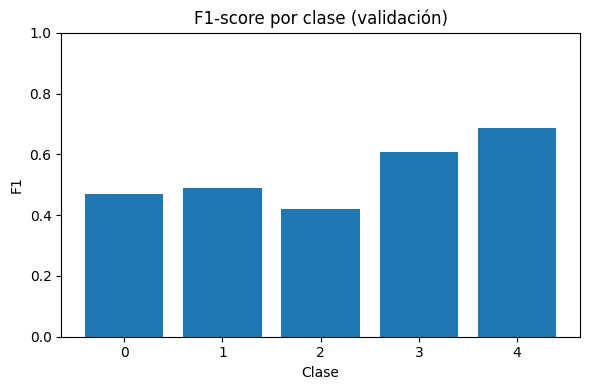

In [17]:
# ========= F1 macro/micro/por clase =========
from sklearn.metrics import classification_report, f1_score
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

OUT = Path("resultados_dl"); OUT.mkdir(parents=True, exist_ok=True)

f1_macro = f1_score(y_true, y_pred, average="macro")
f1_micro = f1_score(y_true, y_pred, average="micro")
rep = classification_report(y_true, y_pred, output_dict=True, digits=4)
rep_df = pd.DataFrame(rep).T
rep_df.to_csv(OUT / "classification_report_val.csv")

print(f"F1-macro: {f1_macro:.4f} | F1-micro: {f1_micro:.4f}")
display(rep_df)

# Gráfico de F1 por clase
cls_rows = [str(i) for i in range(N_CLASSES) if str(i) in rep_df.index]
plt.figure(figsize=(6,4))
plt.bar(cls_rows, rep_df.loc[cls_rows, "f1-score"].values)
plt.title("F1-score por clase (validación)")
plt.xlabel("Clase"); plt.ylabel("F1"); plt.ylim(0,1)
plt.tight_layout(); plt.savefig(OUT / "f1_por_clase_val.png", dpi=140); plt.show()

# Log to W&B: métricas y figura
try:
    wandb.log({
        "val/f1_macro": float(f1_macro),
        "val/f1_micro": float(f1_micro),
        "val/classification_report": wandb.Table(dataframe=rep_df.reset_index()),
        "val/f1_plot": wandb.Image(str(OUT / "f1_por_clase_val.png"))
    })
    # Subir el CSV como Artifact en lugar de usar wandb.save (evita symlink en Windows)
    try:
        artifact = wandb.Artifact("classification_report_val", type="report")
        artifact.add_file(str(OUT / "classification_report_val.csv"))
        run.log_artifact(artifact)
    except Exception as e:
        print("[W&B] Error subiendo artifact de classification_report:", e)
except Exception as e:
    print("[W&B] No se pudo loguear F1/tabla/figura:", e)


IoU por clase: {0: 0.3057, 1: 0.3226, 2: 0.2657, 3: 0.4351, 4: 0.5227}
IoU macro   : 0.3704


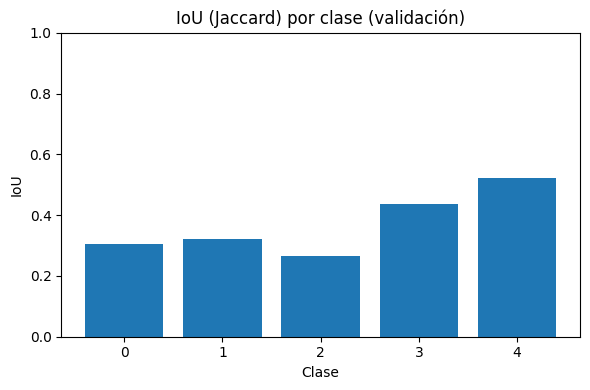

In [20]:
# ========= IoU (Jaccard) por clase =========
from sklearn.metrics import confusion_matrix
import numpy as np

cm = confusion_matrix(y_true, y_pred, labels=np.arange(N_CLASSES))
# TP: diagonal
TP = np.diag(cm).astype(float)
# FP: suma columna k menos TP_k
FP = cm.sum(axis=0) - TP
# FN: suma fila k menos TP_k
FN = cm.sum(axis=1) - TP
IoU = TP / np.clip(TP + FP + FN, 1e-9, None)
IoU_macro = np.nanmean(IoU)

print("IoU por clase:", {i: round(v,4) for i,v in enumerate(IoU)})
print("IoU macro   :", round(IoU_macro,4))

# Guardar CSV + gráfico
iou_df = pd.DataFrame({"clase": np.arange(N_CLASSES), "IoU": IoU})
iou_df.to_csv(OUT / "iou_por_clase_val.csv", index=False)

plt.figure(figsize=(6,4))
plt.bar(iou_df["clase"].astype(str).values, iou_df["IoU"].values)
plt.title("IoU (Jaccard) por clase (validación)")
plt.xlabel("Clase"); plt.ylabel("IoU"); plt.ylim(0,1)
plt.tight_layout(); plt.savefig(OUT / "iou_por_clase_val.png", dpi=140); plt.show()

# Log to W&B
try:
    wandb.log({
        "val/iou_macro": float(IoU_macro),
        "val/iou_by_class": wandb.Table(dataframe=iou_df),
        "val/iou_plot": wandb.Image(str(OUT / "iou_por_clase_val.png"))
    })
    # Subir CSV de IoU como Artifact (evitar wandb.save en Windows)
    try:
        artifact = wandb.Artifact("iou_por_clase_val", type="metrics")
        artifact.add_file(str(OUT / "iou_por_clase_val.csv"))
        run.log_artifact(artifact)
    except Exception as e:
        print("[W&B] Error subiendo artifact de IoU:", e)
    
except Exception as e:
    print("[W&B] No se pudo loguear IoU:", e)


AUC macro: 0.8381 | AUC micro: 0.8454


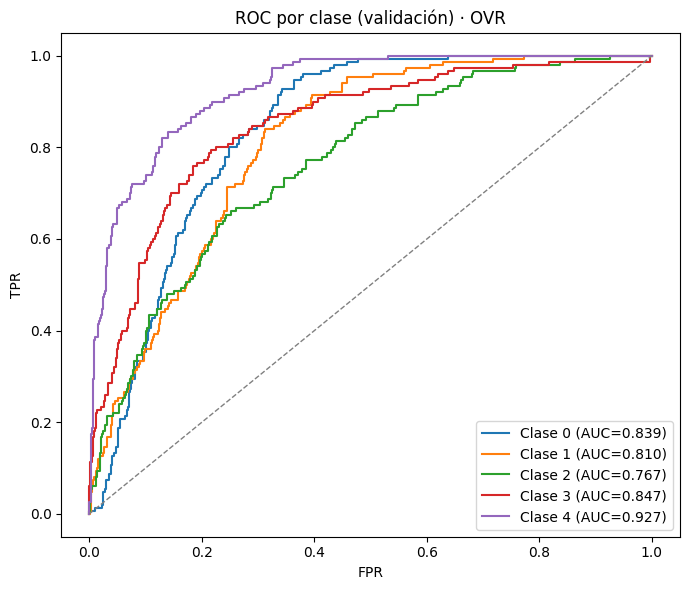

In [21]:
# ========= ROC/AUC multi-clase =========
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc, roc_auc_score

# binariza y_true a one-hot
y_true_bin = label_binarize(y_true, classes=np.arange(N_CLASSES))  # (N, C)

# AUC macro/micro (usando probabilidades por clase)
auc_macro = roc_auc_score(y_true_bin, y_prob, average="macro", multi_class="ovr")
auc_micro = roc_auc_score(y_true_bin, y_prob, average="micro", multi_class="ovr")
print(f"AUC macro: {auc_macro:.4f} | AUC micro: {auc_micro:.4f}")

# Curvas ROC por clase (one-vs-rest)
plt.figure(figsize=(7,6))
for k in range(N_CLASSES):
    fpr, tpr, _ = roc_curve(y_true_bin[:, k], y_prob[:, k])
    cls_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"Clase {k} (AUC={cls_auc:.3f})")

plt.plot([0,1],[0,1],"--", lw=1, color="gray")
plt.xlabel("FPR"); plt.ylabel("TPR")
plt.title("ROC por clase (validación) · OVR")
plt.legend(loc="lower right")
plt.tight_layout(); plt.savefig(OUT / "roc_ovr_val.png", dpi=140); plt.show()

# Log to W&B: AUCs + figura
try:
    wandb.log({
        "val/auc_macro": float(auc_macro),
        "val/auc_micro": float(auc_micro),
        "val/roc_plot": wandb.Image(str(OUT / "roc_ovr_val.png"))
    })
except Exception as e:
    print("[W&B] No se pudo loguear ROC/AUC:", e)


In [22]:
try:
    run.finish()
except Exception:
    pass

epoch,▁▂▂▃▄▅▅▆▇▇█
lr,███▇▇▆▅▄▃▂▁
train/loss,█▆▅▅▄▄▃▃▂▁▁
val/acc,▁▃▄▆▆█▇▅▅▆▇
val/auc_macro,▁
val/auc_micro,▁
val/f1_macro,▁▁
val/f1_micro,▁▁
val/iou_macro,▁
val/loss,█▇▃▂▃▁▃▇▅▇▅
epoch,11


In [ ]:
# ----------------------------
# Evaluación en el split de validación
# ----------------------------
model.eval()
ys, ps = [], []
with torch.no_grad():
    for xb, yb in DataLoader(CSVImages(df_va, tfm_va), batch_size=BATCH, shuffle=False,
                             num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY):
        xb = xb.to(DEVICE, non_blocking=True)
        pred = model(xb).argmax(1).cpu().numpy()
        ys.extend(yb.numpy().tolist()); ps.extend(pred.tolist())

rep = classification_report(ys, ps, output_dict=True, zero_division=0)
pd.DataFrame(rep).transpose().to_csv(OUTDIR/"cls_report_val.csv")

cm = confusion_matrix(ys, ps, labels=list(range(N_CLASSES)))
fig, ax = plt.subplots(figsize=(5,4), dpi=140)
im = ax.imshow(cm, cmap="viridis")
ax.set_xlabel("Predicted"); ax.set_ylabel("True"); ax.set_title("Confusion • VAL (combined)")
ax.set_xticks(range(N_CLASSES)); ax.set_yticks(range(N_CLASSES))
for i in range(N_CLASSES):
    for j in range(N_CLASSES):
        ax.text(j, i, int(cm[i, j]), ha="center", va="center",
                color="white" if cm[i,j] > cm.max()*0.6 else "black", fontsize=8)
plt.colorbar(im, fraction=0.046, pad=0.04)
plt.tight_layout(); plt.savefig(OUTDIR/"confmat_val.png", bbox_inches="tight"); plt.close()

# Log to Weights & Biases
try:
    import wandb
    wandb.log({
        "val/confusion_matrix": wandb.plot.confusion_matrix(
            y_true=ys, preds=ps, class_names=[str(i) for i in range(N_CLASSES)]
        )
    })
except Exception as e:
    print("[W&B] No se pudo loguear la matriz de confusión:", e)

In [19]:
# ---- Mostrar info del run y listar artifacts subidos (si hay) - versión robusta
import wandb
wb = globals().get('run', None) or getattr(wandb, 'run', None)
print('wandb.run:', wb)
if wb is None:
    print('No hay run activo en el namespace actual.')
else:
    try:
        print('run.name :', getattr(wb, 'name', None))
        print('run.id   :', getattr(wb, 'id', None))
        print('run.project:', getattr(wb, 'project', None))
        print('run.entity :', getattr(wb, 'entity', None))
        print('run.dir  :', getattr(wb, 'dir', None))
        # Intentar método directo (puede no existir)
        try:
            arts = list(wb.logged_artifacts())
            print('\nArtifacts via wb.logged_artifacts() (count={}):'.format(len(arts)))
            for i, a in enumerate(arts):
                print(i, a.name, a.type)
        except Exception as e1:
            print('\nwb.logged_artifacts() no disponible:', e1)
            # Intentar vía API
            try:
                api = wandb.Api()
                ent = getattr(wb, 'entity', None) or api.default_entity
                proj = getattr(wb, 'project', None) or api.default_project
                run_id = getattr(wb, 'id', None)
                if ent and proj and run_id:
                    run_ref = api.run(f"{ent}/{proj}/{run_id}")
                    listed = list(run_ref.logged_artifacts())
                    print('\nArtifacts via Api.run(...).logged_artifacts() (count={}):'.format(len(listed)))
                    for i, a in enumerate(listed):
                        print(i, a.name, a.type)
                else:
                    print('No se pudo construir referencia Api.run: faltan ent/proj/id')
            except Exception as e2:
                print('No se pudo listar artifacts via API:', e2)
    except Exception as e:
        print('No se pudo listar artifacts:', e)


wandb.run: <wandb.sdk.wandb_run.Run object at 0x000002DAB0D0B220>
run.name : mobilenet_v3_large_img224_bs8_lr0.0003
run.id   : 5ro96w2t
run.project: retinopatia-diabetica
run.entity : victoria-castro-universidad-peruana-cayetano-heredia
run.dir  : C:\Users\Victoria\Desktop\data\datos_raw\resultados_dl\_wandb_runs\wandb\run-20251117_150724-5ro96w2t\files

wb.logged_artifacts() no disponible: 'Run' object has no attribute 'logged_artifacts'

Artifacts via Api.run(...).logged_artifacts() (count=8):
0 run-5ro96w2t-valconfusion_matrix_table-abYBwg:v0 run_table
1 run-5ro96w2t-valconfusion_matrix_table-abYBwg:v1 run_table
2 run-5ro96w2t-valconfusion_matrix_table-abYBwg:v2 run_table
3 run-5ro96w2t-valconfusion_matrix_table-abYBwg:v3 run_table
4 run-5ro96w2t-valconfusion_matrix_table-abYBwg:v4 run_table
5 run-5ro96w2t-valconfusion_matrix_table-abYBwg:v5 run_table
6 run-5ro96w2t-valclassification_report-pB713w:v0 run_table
7 classification_report_val:v0 report


In [23]:
# ========= BACKFILL: Calcular métricas para otros modelos entrenados (sin reentrenamiento) =========
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.metrics import classification_report, confusion_matrix, f1_score, roc_curve, auc, roc_auc_score
from sklearn.preprocessing import label_binarize
import wandb

# Definir modelos a backfill (que ya tienen best.pth guardado)
models_to_backfill = [
    {
        "arch": "resnet34",
        "img_size": 224,
        "outdir": Path(r"C:\Users\Victoria\Desktop\data\datos_raw\resultados_dl\COMBINED_TRAIN_ONLY_aptos_2019-eyePACS-idrid-messidor_resnet34_img224_bs8_lr0.0003"),
        "run_name": "resnet34_img224_bs8_lr0.0003"
    },
    {
        "arch": "efficientnet_b0",
        "img_size": 224,
        "outdir": Path(r"C:\Users\Victoria\Desktop\data\datos_raw\resultados_dl\efficientnet_b0_"),
        "run_name": "efficientnet_b0_img224_bs8_lr0.0003"
    },
    {
        "arch": "inception_v3",
        "img_size": 299,
        "outdir": Path(r"C:\Users\Victoria\Desktop\data\datos_raw\resultados_dl\inception_v3"),
        "run_name": "inception_v3_img299_bs8_lr0.0003"
    }
]

print("[BACKFILL] Iniciando cálculo de métricas para modelos entrenados...\n")

for model_cfg in models_to_backfill:
    print(f"\n{'='*70}")
    print(f"[{model_cfg['arch'].upper()}] Procesando: {model_cfg['outdir'].name}")
    print(f"{'='*70}")
    
    arch = model_cfg["arch"]
    img_size = model_cfg["img_size"]
    outdir = model_cfg["outdir"]
    run_name = model_cfg["run_name"]
    best_pth = outdir / "best.pth"
    
    if not best_pth.exists():
        print(f"[SKIP] No existe {best_pth}")
        continue
    
    try:
        # 1. Construir modelo con arquitectura correcta
        print(f"[LOAD] Construyendo {arch}...")
        model_temp = build_model(arch, N_CLASSES).to(DEVICE)
        
        # 2. Cargar pesos
        print(f"[LOAD] Cargando pesos desde {best_pth}...")
        state = torch.load(best_pth, map_location=DEVICE)
        model_temp.load_state_dict(state)
        model_temp.eval()
        
        # 3. Crear transforms con IMG_SIZE correcto
        from torchvision.transforms import InterpolationMode
        tfm_temp = transforms.Compose([
            transforms.Resize(img_size, interpolation=InterpolationMode.BILINEAR),
            transforms.CenterCrop(img_size),
            transforms.ToTensor(),
            transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
        ])
        dl_temp = DataLoader(CSVImages(df_va, tfm_temp),
                             batch_size=BATCH, shuffle=False,
                             num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY)
        
        # 4. Recolectar predicciones
        print(f"[EVAL] Ejecutando inferencia en validación...")
        y_true, y_pred, y_prob = eval_collect(model_temp, dl_temp, DEVICE)
        
        # 5. Calcular métricas F1, IoU, ROC/AUC
        print(f"[METRICS] Calculando F1, IoU, ROC/AUC...")
        f1_macro = f1_score(y_true, y_pred, average="macro")
        f1_micro = f1_score(y_true, y_pred, average="micro")
        
        # IoU (Jaccard)
        cm = confusion_matrix(y_true, y_pred, labels=np.arange(N_CLASSES))
        TP = np.diag(cm).astype(float)
        FP = cm.sum(axis=0) - TP
        FN = cm.sum(axis=1) - TP
        IoU = TP / np.clip(TP + FP + FN, 1e-9, None)
        IoU_macro = np.nanmean(IoU)
        
        # ROC/AUC
        y_true_bin = label_binarize(y_true, classes=np.arange(N_CLASSES))
        auc_macro = roc_auc_score(y_true_bin, y_prob, average="macro", multi_class="ovr")
        auc_micro = roc_auc_score(y_true_bin, y_prob, average="micro", multi_class="ovr")
        
        print(f"  ✓ F1-macro: {f1_macro:.4f} | F1-micro: {f1_micro:.4f}")
        print(f"  ✓ IoU-macro: {IoU_macro:.4f}")
        print(f"  ✓ AUC-macro: {auc_macro:.4f} | AUC-micro: {auc_micro:.4f}")
        
        # 6. Guardar reportes y gráficos locales
        print(f"[SAVE] Guardando reportes locales...")
        rep = classification_report(y_true, y_pred, output_dict=True, digits=4)
        rep_df = pd.DataFrame(rep).T
        rep_df.to_csv(outdir / "classification_report_val.csv")
        
        iou_df = pd.DataFrame({"clase": np.arange(N_CLASSES), "IoU": IoU})
        iou_df.to_csv(outdir / "iou_por_clase_val.csv", index=False)
        
        # Gráficos
        fig, ax = plt.subplots(figsize=(6,4), dpi=140)
        ax.bar([str(i) for i in range(N_CLASSES) if str(i) in rep_df.index], 
               rep_df.loc[[str(i) for i in range(N_CLASSES) if str(i) in rep_df.index], "f1-score"].values)
        ax.set_title(f"F1-score por clase ({arch})")
        ax.set_xlabel("Clase"); ax.set_ylabel("F1"); ax.set_ylim(0,1)
        plt.tight_layout(); plt.savefig(outdir / "f1_por_clase_val.png", dpi=140); plt.close()
        
        fig, ax = plt.subplots(figsize=(6,4), dpi=140)
        ax.bar(iou_df["clase"].astype(str).values, iou_df["IoU"].values)
        ax.set_title(f"IoU (Jaccard) por clase ({arch})")
        ax.set_xlabel("Clase"); ax.set_ylabel("IoU"); ax.set_ylim(0,1)
        plt.tight_layout(); plt.savefig(outdir / "iou_por_clase_val.png", dpi=140); plt.close()
        
        # ROC curves
        fig, ax = plt.subplots(figsize=(7,6), dpi=140)
        for k in range(N_CLASSES):
            fpr, tpr, _ = roc_curve(y_true_bin[:, k], y_prob[:, k])
            cls_auc = auc(fpr, tpr)
            ax.plot(fpr, tpr, label=f"Clase {k} (AUC={cls_auc:.3f})")
        ax.plot([0,1],[0,1],"--", lw=1, color="gray")
        ax.set_xlabel("FPR"); ax.set_ylabel("TPR")
        ax.set_title(f"ROC por clase ({arch}) · OVR")
        ax.legend(loc="lower right")
        plt.tight_layout(); plt.savefig(outdir / "roc_ovr_val.png", dpi=140); plt.close()
        
        print(f"  ✓ Reportes guardados en: {outdir}")
        
        # 7. Subir a W&B en el run correspondiente
        print(f"[W&B] Iniciando run en wandb...")
        try:
            wb_run = wandb.init(
                project="retinopatia-diabetica",
                entity="victoria-castro-universidad-peruana-cayetano-heredia",
                name=run_name,
                tags=["DL", "BACKFILL", arch],
                dir=str(WANDB_LOCAL_DIR),
                config={
                    "arch": arch,
                    "img_size": img_size,
                    "model_source": str(outdir),
                    "backfill": True
                }
            )
            
            # Log métricas
            wb_run.log({
                "val/f1_macro": float(f1_macro),
                "val/f1_micro": float(f1_micro),
                "val/iou_macro": float(IoU_macro),
                "val/auc_macro": float(auc_macro),
                "val/auc_micro": float(auc_micro),
                "val/classification_report": wandb.Table(dataframe=rep_df.reset_index()),
                "val/iou_by_class": wandb.Table(dataframe=iou_df),
                "val/f1_plot": wandb.Image(str(outdir / "f1_por_clase_val.png")),
                "val/iou_plot": wandb.Image(str(outdir / "iou_por_clase_val.png")),
                "val/roc_plot": wandb.Image(str(outdir / "roc_ovr_val.png"))
            })
            
            # Subir artifacts
            try:
                artifact_rep = wandb.Artifact("classification_report_val", type="report")
                artifact_rep.add_file(str(outdir / "classification_report_val.csv"))
                wb_run.log_artifact(artifact_rep)
            except Exception as e:
                print(f"  [W&B] Error subiendo artifact de classification_report: {e}")
            
            try:
                artifact_iou = wandb.Artifact("iou_por_clase_val", type="metrics")
                artifact_iou.add_file(str(outdir / "iou_por_clase_val.csv"))
                wb_run.log_artifact(artifact_iou)
            except Exception as e:
                print(f"  [W&B] Error subiendo artifact de IoU: {e}")
            
            wb_run.finish()
            print(f"  ✓ Métricas subidas a W&B (run: {run_name})")
        
        except Exception as e:
            print(f"  [W&B] Error en wandb: {e}")
        
        # Limpiar GPU
        del model_temp, dl_temp
        torch.cuda.empty_cache()
        
    except Exception as e:
        print(f"[ERROR] {arch}: {e}")
        import traceback
        traceback.print_exc()

print(f"\n{'='*70}")
print("[BACKFILL] ✅ Completado. Revisa W&B para ver todas las métricas.")
print(f"{'='*70}\n")

[BACKFILL] Iniciando cálculo de métricas para modelos entrenados...


[RESNET34] Procesando: COMBINED_TRAIN_ONLY_aptos_2019-eyePACS-idrid-messidor_resnet34_img224_bs8_lr0.0003
[LOAD] Construyendo resnet34...
[LOAD] Cargando pesos desde C:\Users\Victoria\Desktop\data\datos_raw\resultados_dl\COMBINED_TRAIN_ONLY_aptos_2019-eyePACS-idrid-messidor_resnet34_img224_bs8_lr0.0003\best.pth...
[EVAL] Ejecutando inferencia en validación...
[LOAD] Cargando pesos desde C:\Users\Victoria\Desktop\data\datos_raw\resultados_dl\COMBINED_TRAIN_ONLY_aptos_2019-eyePACS-idrid-messidor_resnet34_img224_bs8_lr0.0003\best.pth...
[EVAL] Ejecutando inferencia en validación...
[METRICS] Calculando F1, IoU, ROC/AUC...
  ✓ F1-macro: 0.4970 | F1-micro: 0.4947
  ✓ IoU-macro: 0.3338
  ✓ AUC-macro: 0.8291 | AUC-micro: 0.8334
[SAVE] Guardando reportes locales...
[METRICS] Calculando F1, IoU, ROC/AUC...
  ✓ F1-macro: 0.4970 | F1-micro: 0.4947
  ✓ IoU-macro: 0.3338
  ✓ AUC-macro: 0.8291 | AUC-micro: 0.8334
[SAVE] Guardando 

val/auc_macro,▁
val/auc_micro,▁
val/f1_macro,▁
val/f1_micro,▁
val/iou_macro,▁
val/auc_macro,0.82914
val/auc_micro,0.83344
val/f1_macro,0.497
val/f1_micro,0.49467
val/iou_macro,0.33379


  ✓ Métricas subidas a W&B (run: resnet34_img224_bs8_lr0.0003)

[EFFICIENTNET_B0] Procesando: efficientnet_b0_
[LOAD] Construyendo efficientnet_b0...
[LOAD] Cargando pesos desde C:\Users\Victoria\Desktop\data\datos_raw\resultados_dl\efficientnet_b0_\best.pth...
[EVAL] Ejecutando inferencia en validación...
[METRICS] Calculando F1, IoU, ROC/AUC...
  ✓ F1-macro: 0.4962 | F1-micro: 0.4973
  ✓ IoU-macro: 0.3345
  ✓ AUC-macro: 0.8259 | AUC-micro: 0.8317
[SAVE] Guardando reportes locales...
[METRICS] Calculando F1, IoU, ROC/AUC...
  ✓ F1-macro: 0.4962 | F1-micro: 0.4973
  ✓ IoU-macro: 0.3345
  ✓ AUC-macro: 0.8259 | AUC-micro: 0.8317
[SAVE] Guardando reportes locales...
  ✓ Reportes guardados en: C:\Users\Victoria\Desktop\data\datos_raw\resultados_dl\efficientnet_b0_
[W&B] Iniciando run en wandb...
  ✓ Reportes guardados en: C:\Users\Victoria\Desktop\data\datos_raw\resultados_dl\efficientnet_b0_
[W&B] Iniciando run en wandb...


val/auc_macro,▁
val/auc_micro,▁
val/f1_macro,▁
val/f1_micro,▁
val/iou_macro,▁
val/auc_macro,0.82588
val/auc_micro,0.83173
val/f1_macro,0.49617
val/f1_micro,0.49733
val/iou_macro,0.33451


  ✓ Métricas subidas a W&B (run: efficientnet_b0_img224_bs8_lr0.0003)

[INCEPTION_V3] Procesando: inception_v3
[LOAD] Construyendo inception_v3...
[LOAD] Cargando pesos desde C:\Users\Victoria\Desktop\data\datos_raw\resultados_dl\inception_v3\best.pth...
[EVAL] Ejecutando inferencia en validación...
[LOAD] Cargando pesos desde C:\Users\Victoria\Desktop\data\datos_raw\resultados_dl\inception_v3\best.pth...
[EVAL] Ejecutando inferencia en validación...
[METRICS] Calculando F1, IoU, ROC/AUC...
  ✓ F1-macro: 0.4761 | F1-micro: 0.4787
  ✓ IoU-macro: 0.3159
  ✓ AUC-macro: 0.8243 | AUC-micro: 0.8269
[SAVE] Guardando reportes locales...
[METRICS] Calculando F1, IoU, ROC/AUC...
  ✓ F1-macro: 0.4761 | F1-micro: 0.4787
  ✓ IoU-macro: 0.3159
  ✓ AUC-macro: 0.8243 | AUC-micro: 0.8269
[SAVE] Guardando reportes locales...
  ✓ Reportes guardados en: C:\Users\Victoria\Desktop\data\datos_raw\resultados_dl\inception_v3
[W&B] Iniciando run en wandb...
  ✓ Reportes guardados en: C:\Users\Victoria\Desktop\d

val/auc_macro,▁
val/auc_micro,▁
val/f1_macro,▁
val/f1_micro,▁
val/iou_macro,▁
val/auc_macro,0.82435
val/auc_micro,0.82692
val/f1_macro,0.47612
val/f1_micro,0.47867
val/iou_macro,0.31588


  ✓ Métricas subidas a W&B (run: inception_v3_img299_bs8_lr0.0003)

[BACKFILL] ✅ Completado. Revisa W&B para ver todas las métricas.

